# Basic Visual Checks

This notebook contains lightweight  visual checks for the Gold-layer outputs.

The charts help validate pipeline behavior and provide quick insights into:

- transit event throughput
- ingestion latency signals
- route-level delay patterns

These plots are intended for exploratory inspection rather than production dashboards.

In [0]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

_ = spark.sql("USE azure_streaming_mvp")

## Transit event throughput

Plot the total number of transit events per window to observe pipeline throughput.

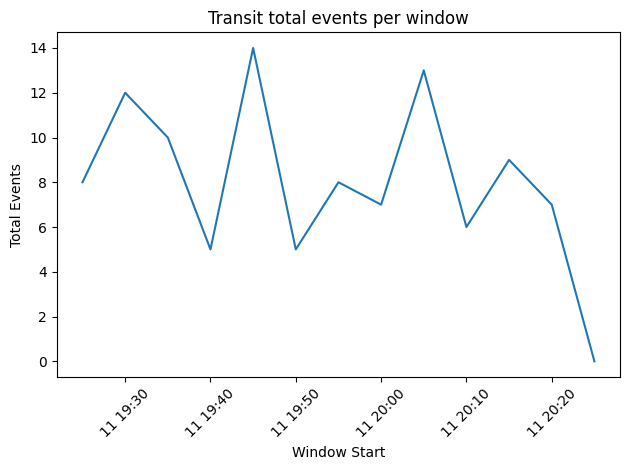

In [0]:
def plot_transit_total_events(table_name="gold_route_kpi_window"):
    """
    Plot total transit events per window (throughput signal).

    Args:
        table_name: Gold table name with route KPIs.
    """

    gold_df = spark.table(table_name)

    volume_df = (
        gold_df
        .groupBy("window_start")
        .agg(
            F.sum(
                F.coalesce(F.col("n_events_delay"), F.lit(0))
            ).alias("transit_total_events")
        )
        .orderBy("window_start")
    )

    pdf = volume_df.toPandas()

    plt.figure()
    plt.plot(pdf["window_start"], pdf["transit_total_events"])
    plt.xticks(rotation=45)
    plt.title("Transit total events per window")
    plt.xlabel("Window Start")
    plt.ylabel("Total Events")
    plt.tight_layout()
    plt.show()

plot_transit_total_events()

## Transit ingestion latency

Plot the average ingestion delay per window to observe latency trends.

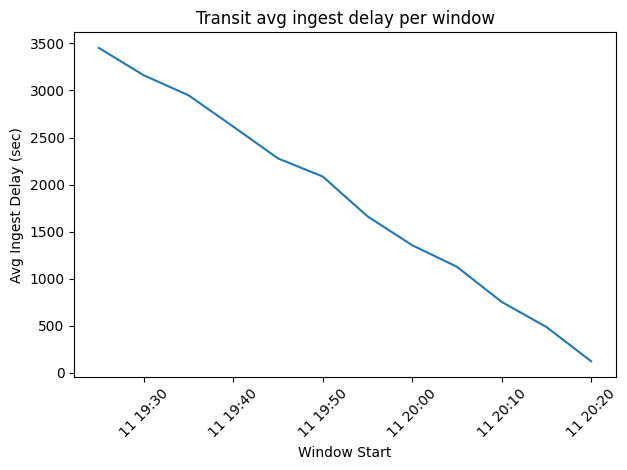

In [0]:
def plot_transit_avg_ingest_delay(table_name="gold_route_kpi_window"):
    """
    Plot average ingest delay per window (latency signal).

    Args:
        table_name: Gold table name with route KPIs.
    """

    gold_df = spark.table(table_name)

    delay_df = (
        gold_df
        .groupBy("window_start")
        .agg(
            F.avg("avg_ingest_delay_sec").alias("transit_avg_ingest_delay_sec")
        )
        .orderBy("window_start")
    )

    pdf = delay_df.toPandas()

    plt.figure()
    plt.plot(pdf["window_start"], pdf["transit_avg_ingest_delay_sec"])
    plt.xticks(rotation=45)
    plt.title("Transit avg ingest delay per window")
    plt.xlabel("Window Start")
    plt.ylabel("Avg Ingest Delay (sec)")
    plt.tight_layout()
    plt.show()

plot_transit_avg_ingest_delay()

## Route delay pattern

Inspect the delay trend for a single route using windowed KPIs.

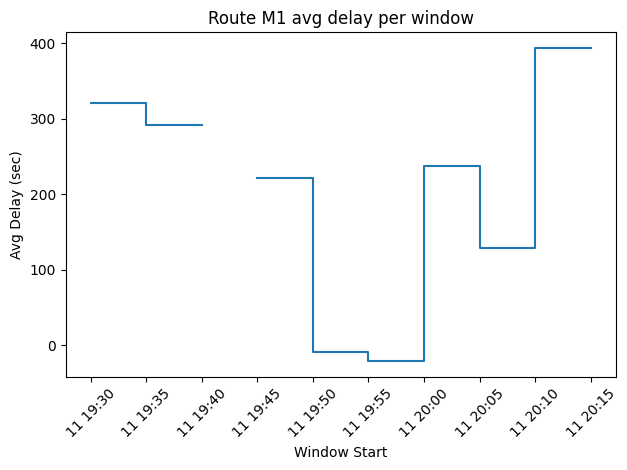

In [0]:
def plot_route_delay_window(route_id: str = "M1", freq: str = "5min"):
    """
    Plot windowed delay KPI for a single route.

    Args:
        route_id: Route identifier (e.g. "M1").
        freq: Pandas offset alias for resampling (e.g. "5min", "15min").

    Notes:
        Missing windows stay as NaN to keep gaps visible.
    """
    gold_df = spark.table("gold_route_kpi_window")

    route_pd = (
        gold_df
        .filter(F.col("route_id") == route_id)
        .select("window_start", "avg_delay_sec")
        .orderBy("window_start")
        .toPandas()
    )

    route_pd["window_start"] = pd.to_datetime(route_pd["window_start"])
    route_pd = route_pd.set_index("window_start").sort_index().asfreq(freq)

    # Ensure numeric type
    route_pd["avg_delay_sec"] = pd.to_numeric(route_pd["avg_delay_sec"], errors="coerce")

    plt.figure()
    plt.step(route_pd.index, route_pd["avg_delay_sec"], where="post")
    plt.xticks(rotation=45)
    plt.title("Route M1 avg delay per window")
    plt.xlabel("Window Start")
    plt.ylabel("Avg Delay (sec)")
    plt.tight_layout()
    plt.show()

# Example
plot_route_delay_window("M1")

In [0]:
# ---- Notebook completion signal ----
dbutils.notebook.exit("OK")